In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

# Locate the project root no matter where the notebook is launched from.
def find_root(markers=('data', 'src')):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if all((parent / m).is_dir() for m in markers):
            return parent
    raise FileNotFoundError('Could not find project root (need data/ and src/).')

ROOT = find_root()
df = pd.read_csv(ROOT / 'data' / 'processed' / 'telco_churn_clean.csv')
print('Shape:', df.shape)
df.head()
df.info()


Shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

Overall churn rate: 26.5%


C:\Users\hp\AppData\Local\Temp\ipykernel_33132\820313803.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])


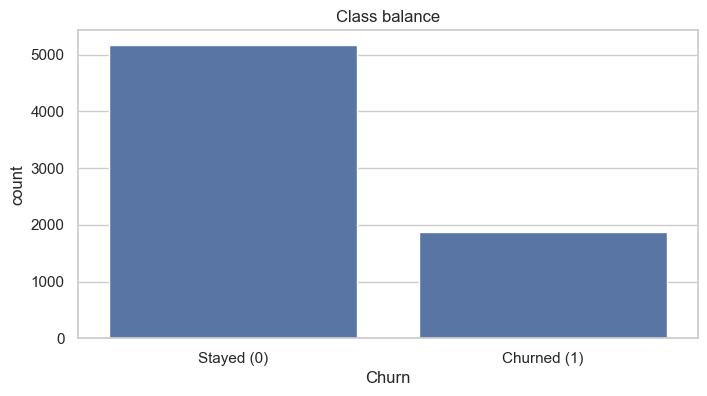

In [3]:
rate = df['Churn'].mean() * 100
print(f'Overall churn rate: {rate:.1f}%')

ax = sns.countplot(x='Churn', data=df)
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])
ax.set_title('Class balance')
plt.show()

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0        37.6            61.3        2549.9
1        18.0            74.4        1531.8


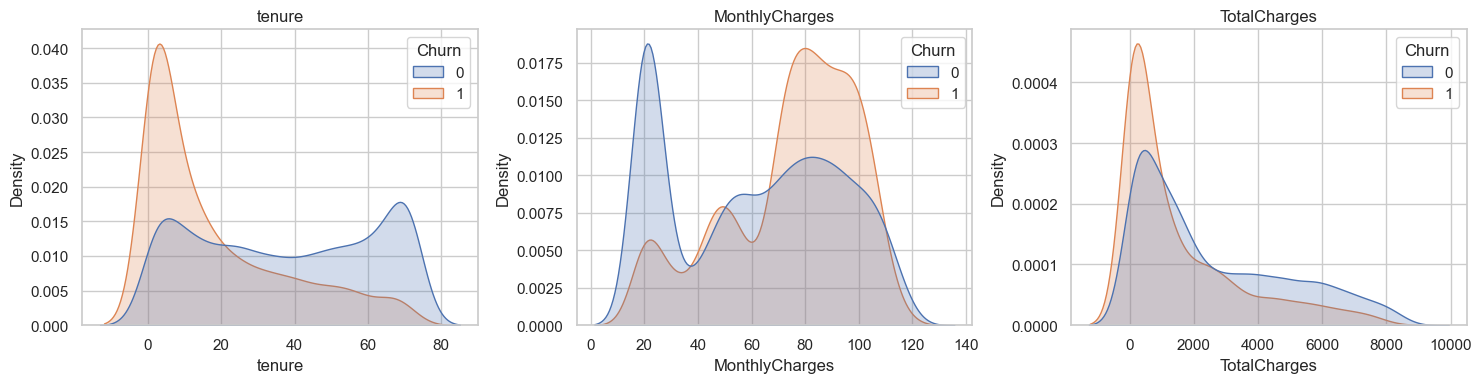

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df.groupby('Churn')[num_cols].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

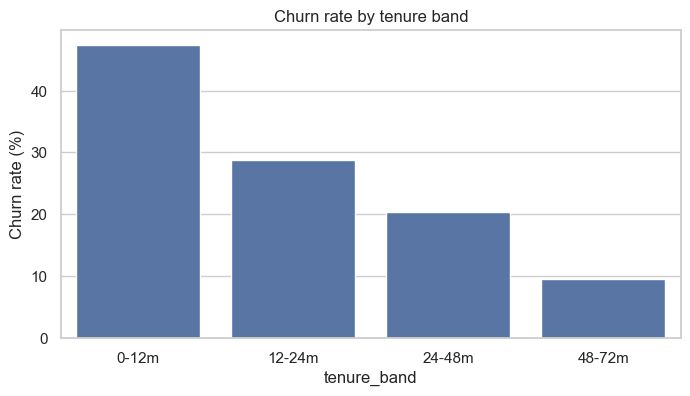

In [5]:
bins = [0, 12, 24, 48, 72]
labels = ['0-12m', '12-24m', '24-48m', '48-72m']
df['tenure_band'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)
rates = df.groupby('tenure_band', observed=True)['Churn'].mean() * 100
ax = sns.barplot(x=rates.index, y=rates.values)
ax.set_title('Churn rate by tenure band')
ax.set_ylabel('Churn rate (%)')
plt.show()
df.drop(columns='tenure_band', inplace=True)

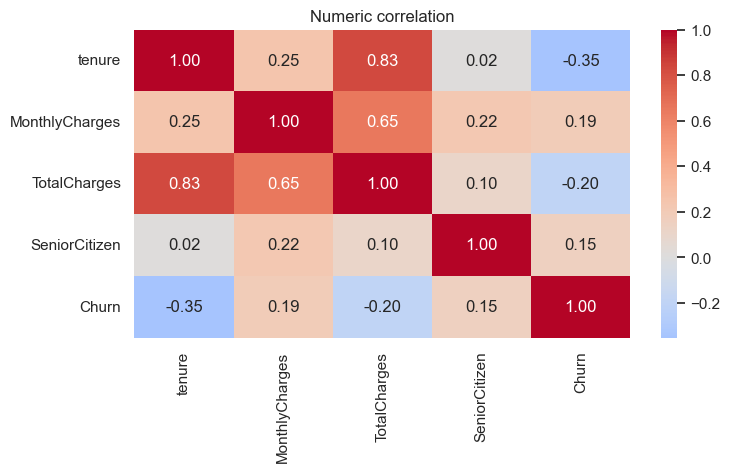

In [6]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numeric correlation')
plt.show()